# Khai phá dữ liệu (EDA) cho Dataset Nhận diện Cháy Nổ (Fire and Smoke)
Notebook này sẽ phân tích các đặc trưng của dataset YOLO gồm các lớp Fire và Smoke. Mục tiêu của phân tích:
- Kiểm tra số lượng hình ảnh và nhãn ở mỗi tập `train`, `val`, `test`.
- Thống kê phân bố giữa các lớp (xem dữ liệu có bị mất cân bằng không).
- Phân tích kích thước và hình dáng của các bounding box (giúp tối ưu hóa anchors cho model YOLO).

In [1]:
import os
import yaml
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Đọc cấu hình dataset từ file data.yaml
dataset_dir = 'dataset'
yaml_path = os.path.join(dataset_dir, 'data.yaml')

with open(yaml_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

class_names = config.get('names', {})
if isinstance(class_names, list):
    class_names = {i: name for i, name in enumerate(class_names)}

print('Các lớp trong dataset:', class_names)

Các lớp trong dataset: {0: 'smoke', 1: 'fire'}


In [2]:
splits = ['train', 'val', 'test']
stats = {
    'num_images': {'train': 0, 'val': 0, 'test': 0},
    'num_labels': {'train': 0, 'val': 0, 'test': 0},
    'class_counts': {split: defaultdict(int) for split in splits},
    'bboxes': []
}

for split in splits:
    label_dir = os.path.join(dataset_dir, split, 'labels')
    image_dir = os.path.join(dataset_dir, split, 'images')
    
    if not os.path.exists(label_dir) or not os.path.exists(image_dir):
        print(f"Cảnh báo: Không tìm thấy thư mục {split}")
        continue
        
    images = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    stats['num_images'][split] = len(images)
    
    labels = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    stats['num_labels'][split] = len(labels)
    
    for label_file in labels:
        with open(os.path.join(label_dir, label_file), 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    cx, cy, w, h = map(float, parts[1:5])
                    
                    stats['class_counts'][split][class_id] += 1
                    stats['bboxes'].append({
                        'split': split,
                        'class_id': class_id,
                        'w': w,
                        'h': h,
                        'cx': cx,
                        'cy': cy
                    })

print('Số lượng ảnh theo tập:', stats['num_images'])
print('Số lượng file nhãn theo tập:', stats['num_labels'])

Số lượng ảnh theo tập: {'train': 14122, 'val': 3099, 'test': 4306}
Số lượng file nhãn theo tập: {'train': 14122, 'val': 3099, 'test': 4306}


## 1. Phân bố các lớp (Class Distribution)
Đồ thị dưới đây cho thấy số lượng instance (đối tượng) của mỗi lớp (Fire/Smoke) trong các tập dữ liệu khác nhau. Điều này giúp chúng ta nhận biết dataset có cân bằng hay không.

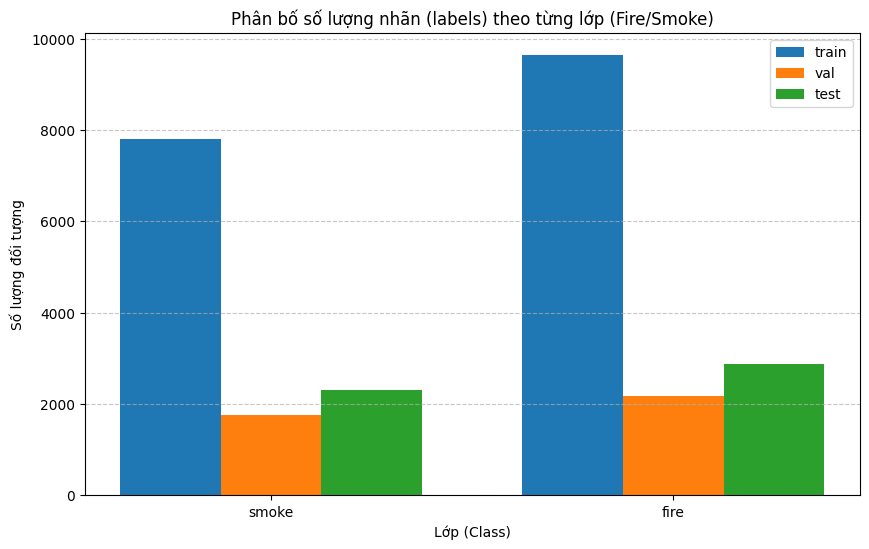

In [3]:
plt.figure(figsize=(10, 6))
bar_width = 0.25

for i, split in enumerate(splits):
    counts = [stats['class_counts'][split].get(cid, 0) for cid in class_names.keys()]
    plt.bar(np.arange(len(class_names)) + i * bar_width, counts, width=bar_width, label=split)
    
plt.xticks(np.arange(len(class_names)) + bar_width, [class_names[k] for k in class_names.keys()])
plt.title('Phân bố số lượng nhãn (labels) theo từng lớp (Fire/Smoke)')
plt.xlabel('Lớp (Class)')
plt.ylabel('Số lượng đối tượng')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Kích thước Bounding Box (Width vs Height)
Đồ thị Scatter dưới đây thể hiện sự phân bố chiều rộng (width) và chiều cao (height) của các bounding box (đã được chuẩn hóa từ 0-1). Thông tin này rất hữu ích cho quá trình K-means Clustering khi tạo anchor boxes trong cấu hình model YOLO.

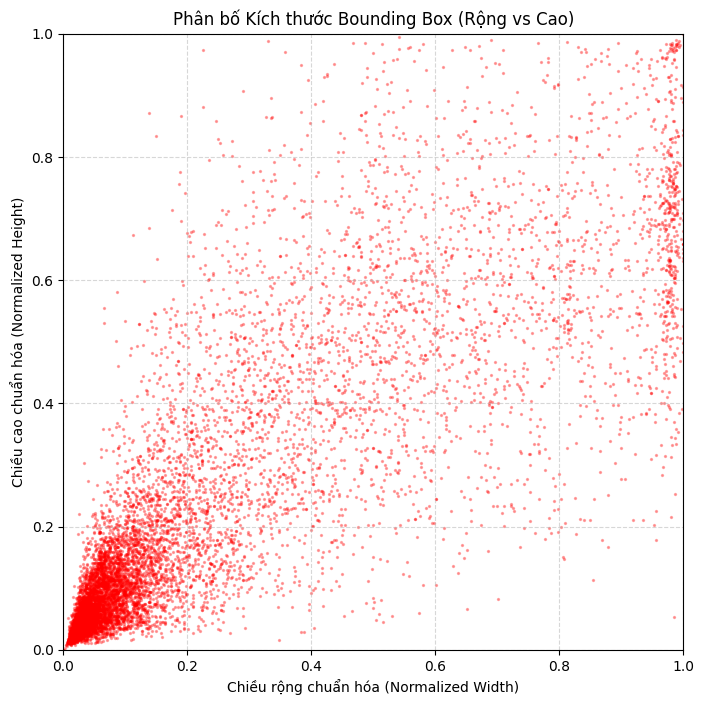

In [4]:
if stats['bboxes']:
    plt.figure(figsize=(8, 8))
    ws = [b['w'] for b in stats['bboxes']]
    hs = [b['h'] for b in stats['bboxes']]
    
    # Lấy mẫu một phần nhỏ nếu số lượng box quá nhiều (giúp render đồ thị nhanh)
    sample_size = min(10000, len(ws))
    indices = np.random.choice(len(ws), sample_size, replace=False)
    ws_sample = [ws[i] for i in indices]
    hs_sample = [hs[i] for i in indices]
    
    plt.scatter(ws_sample, hs_sample, alpha=0.3, s=2, c='red')
    plt.title('Phân bố Kích thước Bounding Box (Rộng vs Cao)')
    plt.xlabel('Chiều rộng chuẩn hóa (Normalized Width)')
    plt.ylabel('Chiều cao chuẩn hóa (Normalized Height)')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(linestyle='--', alpha=0.5)
    plt.show()

## 3. Bản đồ Nhiệt Vị trí Đối tượng (Heatmap of Center Points)
Kiểm tra xem khói và lửa thường xuất hiện ở phần nào của hình ảnh (Trung tâm, góc dưới, góc trên,...).

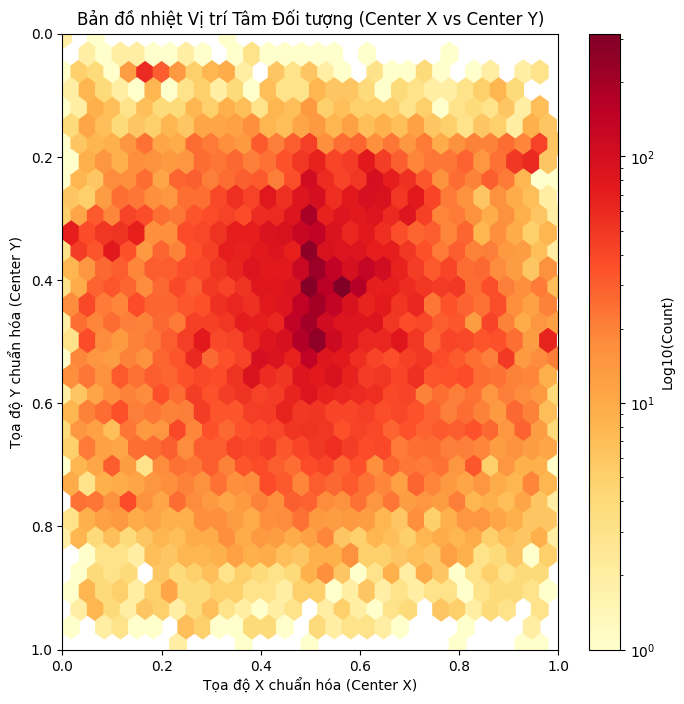

In [5]:
if stats['bboxes']:
    cxs = [b['cx'] for b in stats['bboxes']]
    cys = [b['cy'] for b in stats['bboxes']]
    
    plt.figure(figsize=(8, 8))
    # Dùng đồ thị 2D histogram (hexbin) để làm Heatmap
    plt.hexbin(cxs, cys, gridsize=30, cmap='YlOrRd', bins='log')
    plt.colorbar(label='Log10(Count)')
    plt.title('Bản đồ nhiệt Vị trí Tâm Đối tượng (Center X vs Center Y)')
    plt.xlabel('Tọa độ X chuẩn hóa (Center X)')
    plt.ylabel('Tọa độ Y chuẩn hóa (Center Y)')
    plt.xlim(0, 1)
    plt.ylim(1, 0) # Lộn ngược trục Y cho giống với không gian ảnh gốc
    plt.show()